# 🤖 Notebook 05 — Forecasting Model (LSTM + Transformer)
PyTorch deep learning for 24-hour ahead energy forecasting

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from model import EnergyLSTM, EnergyTransformer, create_sequences, train_model

plt.style.use('seaborn-v0_8-darkgrid')
print('PyTorch version:', torch.__version__)
print('GPU available:', torch.cuda.is_available())

PyTorch version: 2.5.1+cu121
GPU available: True


In [11]:
# ── Load cleaned data ──
df = pd.read_csv('../data/processed/energy_cleaned.csv', index_col=0, parse_dates=True)
energy_col = df.columns[0]
values = df[energy_col].values.reshape(-1, 1)

# Normalize to [0, 1]
scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(values)

print(f'Data shape: {values_scaled.shape}')

Data shape: (121010, 1)


In [12]:
# ── Create sequences ──
LOOKBACK = 168   # 1 week of hourly history
HORIZON  = 24    # predict next 24 hours

X, y = create_sequences(values_scaled, lookback=LOOKBACK, horizon=HORIZON)
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

# Train/test split (80/20, time-ordered)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')

X shape: (120818, 168, 1)  |  y shape: (120818, 24, 1)
Train size: 96,654  |  Test size: 24,164


In [13]:
y_train = y_train.squeeze(-1)
y_test = y_test.squeeze(-1)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

y_train shape: (96654, 24)
y_test shape: (24164, 24)


In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [15]:
# ── Train LSTM ──
lstm_model = EnergyLSTM(
    input_size=1,
    hidden_size=128,
    num_layers=2,
    output_size=HORIZON,
    dropout=0.2
)

print(f'Model parameters: {sum(p.numel() for p in lstm_model.parameters()):,}')
lstm_model = train_model(lstm_model, X_train, y_train, epochs=30, lr=1e-3, batch_size=64)

Model parameters: 202,264
Epoch [5/30]  Loss: 0.0037
Epoch [10/30]  Loss: 0.0028
Epoch [15/30]  Loss: 0.0024
Epoch [20/30]  Loss: 0.0020
Epoch [25/30]  Loss: 0.0017
Epoch [30/30]  Loss: 0.0014
✅ Training complete!


In [16]:
# ── Evaluate ──
lstm_model.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test)
    preds_scaled = lstm_model(X_test_t).numpy()

# Inverse transform
preds  = scaler.inverse_transform(preds_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, HORIZON))

mae  = mean_absolute_error(actual.flatten(), preds.flatten())
rmse = np.sqrt(mean_squared_error(actual.flatten(), preds.flatten()))
mape = np.mean(np.abs((actual.flatten() - preds.flatten()) / actual.flatten())) * 100

print(f'\n📊 LSTM Results:')
print(f'   MAE:  {mae:.2f} MW')
print(f'   RMSE: {rmse:.2f} MW')
print(f'   MAPE: {mape:.2f}%')


📊 LSTM Results:
   MAE:  576.61 MW
   RMSE: 815.96 MW
   MAPE: 3.89%


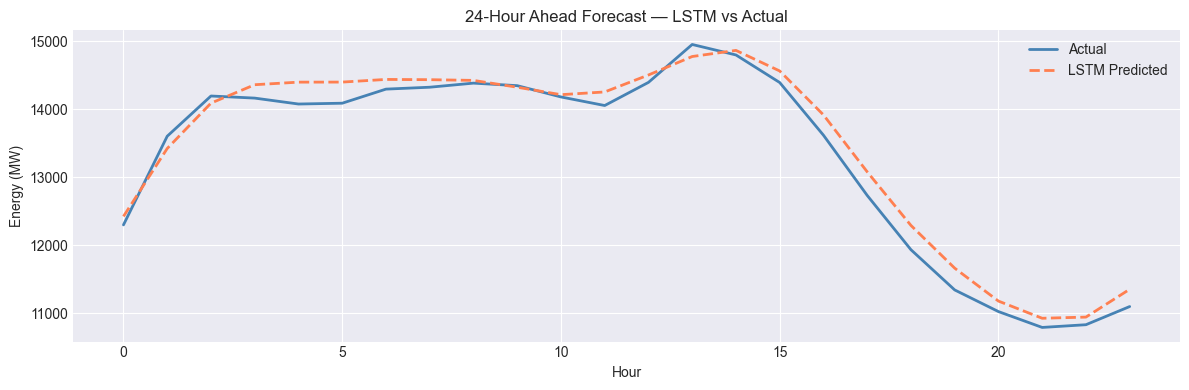

In [17]:
# ── Plot predictions vs actual ──
sample_idx = 100  # pick any test sample

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actual[sample_idx], label='Actual', color='steelblue', linewidth=2)
ax.plot(preds[sample_idx],  label='LSTM Predicted', color='coral', linewidth=2, linestyle='--')
ax.set_title('24-Hour Ahead Forecast — LSTM vs Actual')
ax.set_xlabel('Hour')
ax.set_ylabel('Energy (MW)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/05_lstm_forecast.png', dpi=150)
plt.show()

In [19]:
# ── Save model ──
torch.save(lstm_model.state_dict(), '../data/processed/lstm_model.pth')
print('✅ Model saved!')

# ── Export predictions for Power BI ──
results_df = pd.DataFrame({
    'actual': actual[:200].flatten(),
    'predicted': preds[:200].flatten()
})
results_df.to_csv('../powerbi/dashboard_export.csv', index=False)
print('✅ Exported predictions to powerbi/dashboard_export.csv')


torch.save(lstm_model.state_dict(), '../data/processed/lstm_model.pth')
print('✅ Model saved!')

✅ Model saved!
✅ Exported predictions to powerbi/dashboard_export.csv
✅ Model saved!
